In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(root) not in sys.path:
    sys.path.append(str(root))

HOUSE = os.environ.get("SMART_HOME_HOUSE", "hh101")
processed_path = root / "data" / "processed" / f"{HOUSE}_features_with_models.csv"
if not processed_path.exists():
    raise FileNotFoundError(f"Modeled features not found: {processed_path}")

fig_dir = root / "outputs" / "figures" / HOUSE
table_dir = root / "outputs" / "tables" / HOUSE
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(processed_path)
df["window_start"] = pd.to_datetime(df["window_start"])
df["is_anomaly"] = df["is_anomaly"].astype(str).str.lower().isin({"true", "1", "yes"})
print(f"Loaded {len(df)} modeled windows for {HOUSE} from {processed_path}")

# show top anomalies
anom = df[df["is_anomaly"] & (df["total_events"] > 0)].sort_values("anomaly_score").head(30)
anom.to_csv(table_dir / f"{HOUSE}_top_anomalies.csv", index=False)
anom[["window_start","anomaly_score","total_events","n_sensors_active","cluster"]].head(20)

Loaded 107127 modeled windows for hh101 from C:\Users\evang\Documents\GitHub\smart-home-anomaly-detection\data\processed\hh101_features_with_models.csv


,window_start,anomaly_score,total_events,n_sensors_active,cluster
561,2012-07-20 11:35:00,-0.106645,228.0,6.0,1
23257,2012-10-07 06:55:00,-0.104554,155.0,6.0,1
72830,2013-03-28 10:00:00,-0.104113,204.0,5.0,1
12807,2012-09-01 00:05:00,-0.103106,170.0,6.0,1
55437,2013-01-27 00:35:00,-0.102379,167.0,6.0,1
75591,2013-04-07 00:05:00,-0.101203,193.0,6.0,1
1077,2012-07-22 06:35:00,-0.098539,124.0,6.0,1
45768,2012-12-24 10:50:00,-0.098423,170.0,6.0,1
62921,2013-02-22 00:15:00,-0.098114,160.0,6.0,1
2240,2012-07-26 07:30:00,-0.098010,134.0,6.0,1


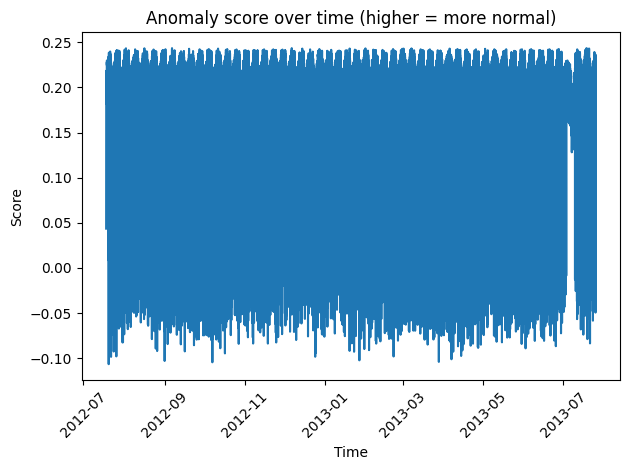

In [2]:
# timeline view of anomaly score
plt.figure()
plt.plot(df["window_start"], df["anomaly_score"])
plt.title("Anomaly score over time (higher = more normal)")
plt.xlabel("Time")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(fig_dir / f"{HOUSE}_anomaly_score_timeline.png", bbox_inches="tight")
plt.show()

In [3]:
# prolonged inactivity detector (interpretation helper)
df["is_inactive"] = df["total_events"] == 0
# count consecutive inactive windows
inactive_run = (df["is_inactive"] != df["is_inactive"].shift()).cumsum()
runs = df[df["is_inactive"]].groupby(inactive_run).size().sort_values(ascending=False)
runs.to_csv(table_dir / f"{HOUSE}_inactive_runs.csv", header=["window_count"])
runs.head(10)

is_inactive
20460    565
2        544
20450    256
20448    179
20456    155
20452    119
20446    109
20458    106
20466     94
20438     77
dtype: int64

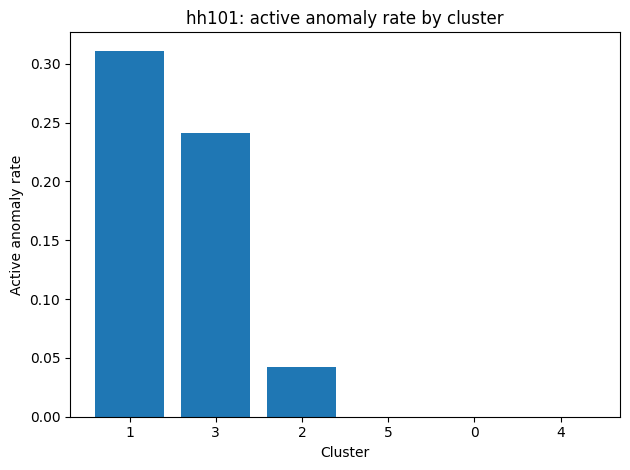

,cluster,windows,anomalies,active_windows,active_anomalies,mean_anomaly_score,anomaly_rate,active_anomaly_rate
1,1,3378,1051,3378,1051,0.0282,0.3111,0.3111
3,3,3664,885,3664,885,0.0319,0.2415,0.2415
2,2,4835,205,4835,205,0.0677,0.0424,0.0424
5,5,33796,2,33796,2,0.2001,0.0001,0.0001
0,0,27669,0,0,0,0.1884,0.0000,NaN
4,4,33785,0,0,0,0.2058,0.0000,NaN


In [4]:
# anomaly rate by cluster
anomaly_by_cluster = (
    df.groupby("cluster")
    .agg(
        windows=("cluster", "size"),
        anomalies=("is_anomaly", "sum"),
        active_windows=("total_events", lambda s: int((s > 0).sum())),
        active_anomalies=("is_anomaly", lambda s: int(s[df.loc[s.index, "total_events"] > 0].sum())),
        mean_anomaly_score=("anomaly_score", "mean"),
    )
    .reset_index()
)
anomaly_by_cluster["anomaly_rate"] = anomaly_by_cluster["anomalies"] / anomaly_by_cluster["windows"]
anomaly_by_cluster["active_anomaly_rate"] = anomaly_by_cluster["active_anomalies"] / anomaly_by_cluster["active_windows"].where(anomaly_by_cluster["active_windows"] > 0)
anomaly_by_cluster = anomaly_by_cluster.sort_values("active_anomaly_rate", ascending=False, na_position="last")
anomaly_by_cluster.to_csv(table_dir / f"{HOUSE}_anomaly_rate_by_cluster.csv", index=False)

plt.figure()
plt.bar(anomaly_by_cluster["cluster"].astype(str), anomaly_by_cluster["active_anomaly_rate"].fillna(0.0))
plt.title(f"{HOUSE}: active anomaly rate by cluster")
plt.xlabel("Cluster")
plt.ylabel("Active anomaly rate")
plt.tight_layout()
plt.savefig(fig_dir / f"{HOUSE}_anomaly_rate_by_cluster.png", bbox_inches="tight")
plt.show()

anomaly_by_cluster.round(4)